autograd only supports numpy < 2.0.0 versions.


<Figure size 700x500 with 0 Axes>

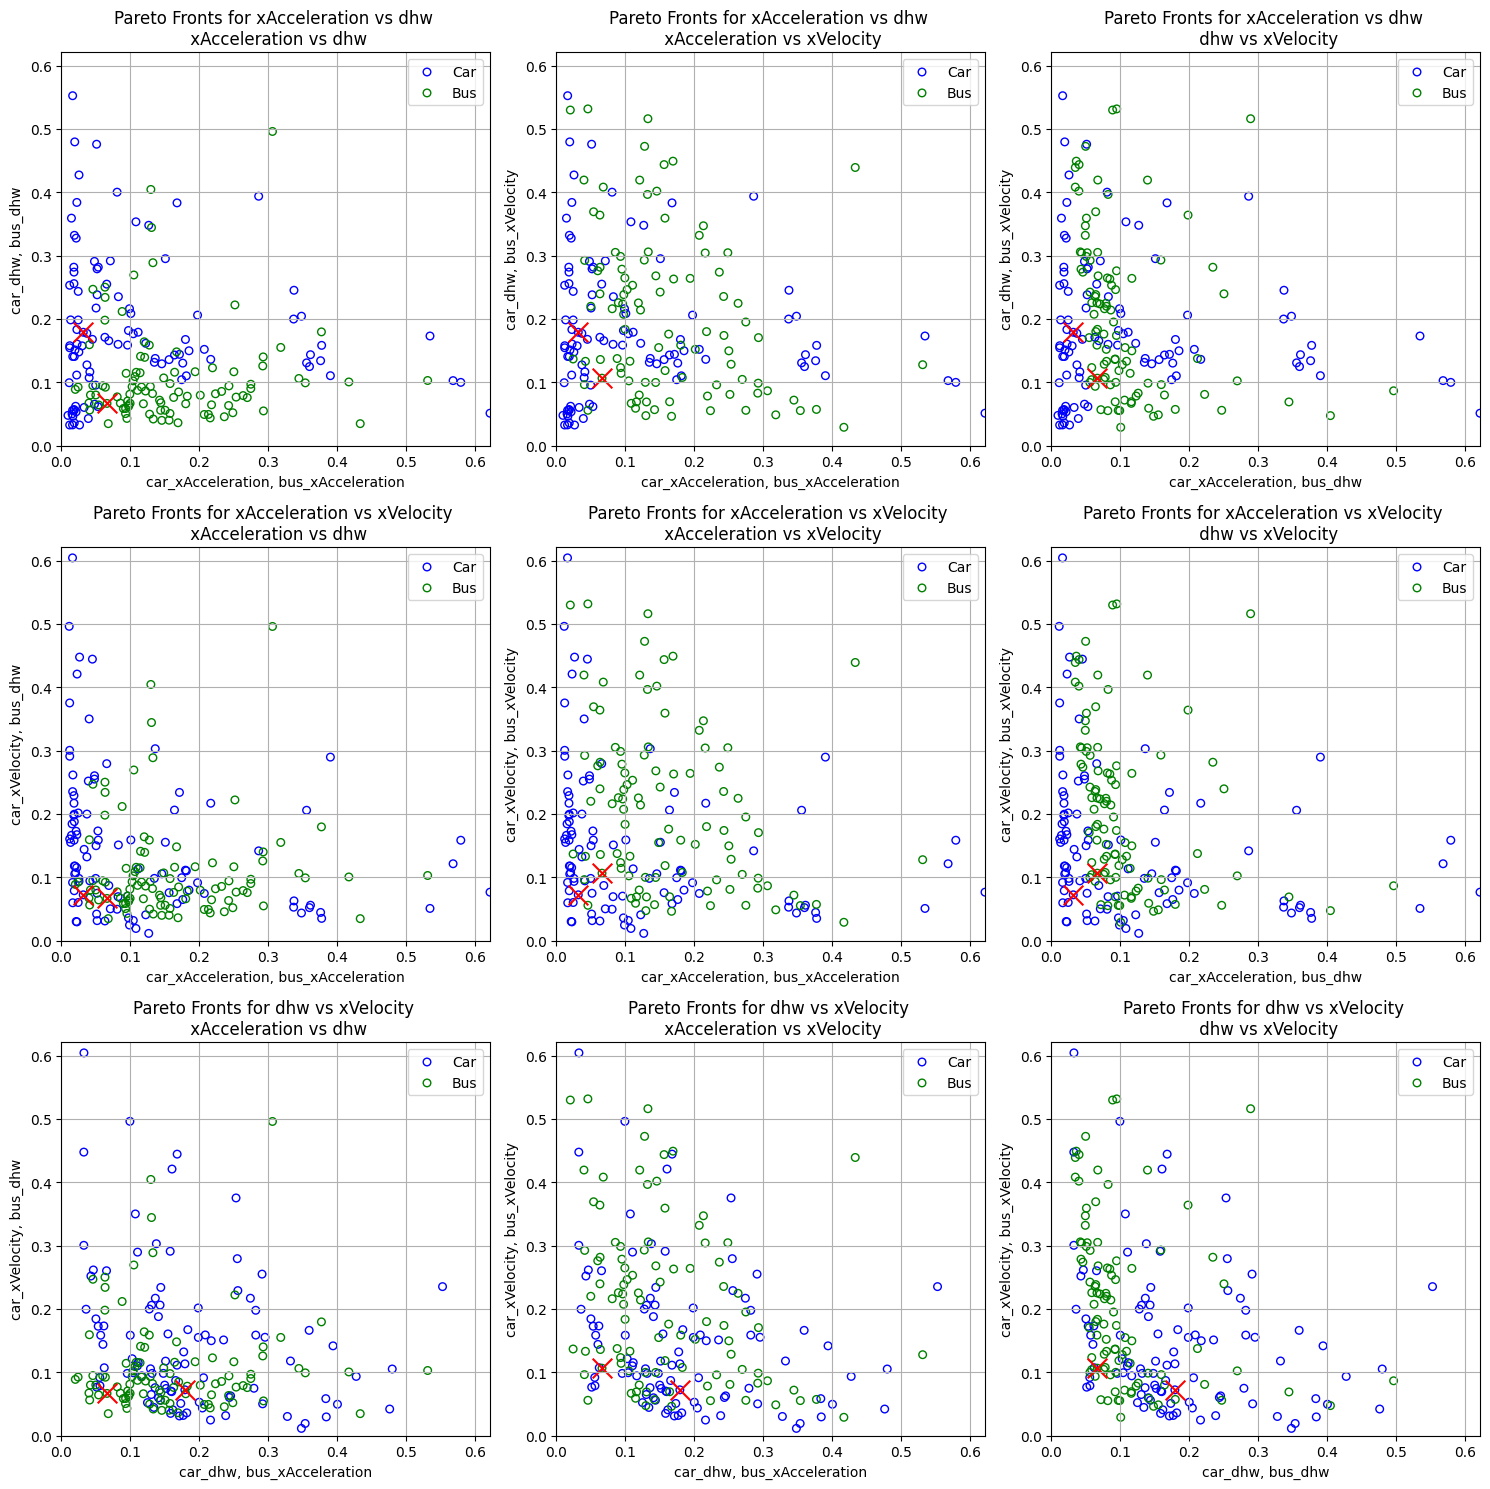

In [1]:

from pymoo.core.problem import ElementwiseProblem
import numpy as np
import time
import random
from task import SUMO_task,pbounds
from pymoo.algorithms.moo.nsga2 import NSGA2
import matplotlib.pyplot as plt
import pickle
from multi_object_optimization import  MooSUMOProblem, SinSUMOProblem


with open('../output/data_cache/age2_result.pkl', 'rb') as f:
# with open('../output/data_cache/sms_result.pkl', 'rb') as f:
    res1 = pickle.load(f)
res  = res1

# Assuming `F` and `problem` are already defined
F = res.F
xl, xu = res.problem.bounds()
fig = plt.figure(figsize=(7, 5))
distance_sums = (np.sum(F, axis=1))
ideal_point_index = np.argmin(np.sum(F, axis=1))

# Get the ideal point
ideal_point = F[ideal_point_index]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
car_fi = ["xAcceleration", "dhw", "xVelocity"]
bus_fi = ["xAcceleration", "dhw", "xVelocity"]

# Flatten the axes array for easier iteration
axes = axes.flatten()
plot_idx = 0
for x, y in [(0, 1), (0, 2), (1, 2)]:
    for x1, y1 in [(3, 4), (3, 5), (4, 5)]:
        ax = axes[plot_idx]
        ax.scatter(F[:, x], F[:, y], s=30, facecolors='none', edgecolors='blue')
        ax.scatter(F[:, x1], F[:, y1], s=30, facecolors='none', edgecolors='green')
        
        # Mark the ideal point
        ax.scatter(ideal_point[x], ideal_point[y], s=200, c='red', marker='x')
        ax.scatter(ideal_point[x1], ideal_point[y1], s=200, c='red', marker='x')
        
        ax.set_xlim([0, max(F[:, 0])])
        ax.set_ylim([0, max(F[:, 0])])
        ax.set_xlabel(f"car_{car_fi[x]}, bus_{bus_fi[x1-3]}")
        ax.set_ylabel(f"car_{car_fi[y]}, bus_{bus_fi[y1-3]}")
        ax.set_title(f"Pareto Fronts for {car_fi[x]} vs {car_fi[y]} \n {bus_fi[x1-3]} vs {bus_fi[y1-3]}")
        ax.legend(["Car", "Bus"])
        ax.grid()
        plot_idx += 1

plt.tight_layout()
plt.show()

In [2]:
from pymoo.core.problem import ElementwiseProblem
import numpy as np
import time
import random
from task import SUMO_task,pbounds
from pymoo.algorithms.moo.nsga2 import NSGA2
import matplotlib.pyplot as plt
import pickle
from multi_object_optimization import  MooSUMOProblem, SinSUMOProblem
Fs = np.array([ind.F for ind in res.history[-1].pop])
sum_F = np.sum(Fs, axis=1)
min_index = np.argmin(sum_F)
min_F = Fs[min_index]
min_X = res.history[-1].pop[min_index].X

# 打印具有最小 F 合计值的个体的参数和 F
print("\n具有最小 F 合计值的个体的参数和 F：")
print("输入参数：", min_X)
print("对应的 F 值：", min_F)
print("F 合计值：", sum_F[min_index]/6)




具有最小 F 合计值的个体的参数和 F：
输入参数： [1.89644704e+00 5.04167203e-01 3.59963598e+00 8.96203206e+00
 1.15711430e+00 2.42453724e-01 2.25409009e+00 2.45852639e+00
 4.79068241e-01 3.20620529e-01 4.06166355e-01 8.91577308e-01
 8.78174897e+00 7.76657841e-02 2.39396395e+01 1.76960481e+01
 1.51389613e-01 2.67013190e-01 7.65199329e-01 7.73358180e-01
 1.28539325e-02 5.06080905e-03 6.55638263e+00 1.38746459e+01
 9.46100750e-01 5.51237047e-01 2.86768571e+01 2.75459350e+01]
对应的 F 值： [0.03165864 0.17891143 0.07225102 0.0660797  0.06657478 0.10643016]
F 合计值： 0.08698428694621889


In [3]:
import time
import random
from task import SUMO_task,pbounds
from pymoo.algorithms.moo.nsga2 import NSGA2
import matplotlib.pyplot as plt
import pickle
from multi_object_optimization import  MooSUMOProblem, SinSUMOProblem
Fs = np.array([ind.F for ind in res.history[-1].pop])
sum_F = np.sum(Fs, axis=1)
min_index = np.argmin(sum_F)
min_F = Fs[min_index]
min_X = res.history[-1].pop[min_index].X

# 打印具有最小 F 合计值的个体的参数和 F
print("\n具有最小 F 合计值的个体的参数和 F：")
print("输入参数：", min_X)
print("对应的 F 值：", min_F)
print("F 合计值：", sum_F[min_index]/6)




具有最小 F 合计值的个体的参数和 F：
输入参数： [1.89644704e+00 5.04167203e-01 3.59963598e+00 8.96203206e+00
 1.15711430e+00 2.42453724e-01 2.25409009e+00 2.45852639e+00
 4.79068241e-01 3.20620529e-01 4.06166355e-01 8.91577308e-01
 8.78174897e+00 7.76657841e-02 2.39396395e+01 1.76960481e+01
 1.51389613e-01 2.67013190e-01 7.65199329e-01 7.73358180e-01
 1.28539325e-02 5.06080905e-03 6.55638263e+00 1.38746459e+01
 9.46100750e-01 5.51237047e-01 2.86768571e+01 2.75459350e+01]
对应的 F 值： [0.03165864 0.17891143 0.07225102 0.0660797  0.06657478 0.10643016]
F 合计值： 0.08698428694621889


In [7]:
def gen_eval_data(min_X):
    param = {key: min_X[i] for i, key in enumerate(pbounds.keys())}
    task = SUMO_task(param)
    res = task.run_task(save=True, gui=False,sim_step=800*30)
    print(res)
# gen_eval_data(min_X)

(3000, 6)


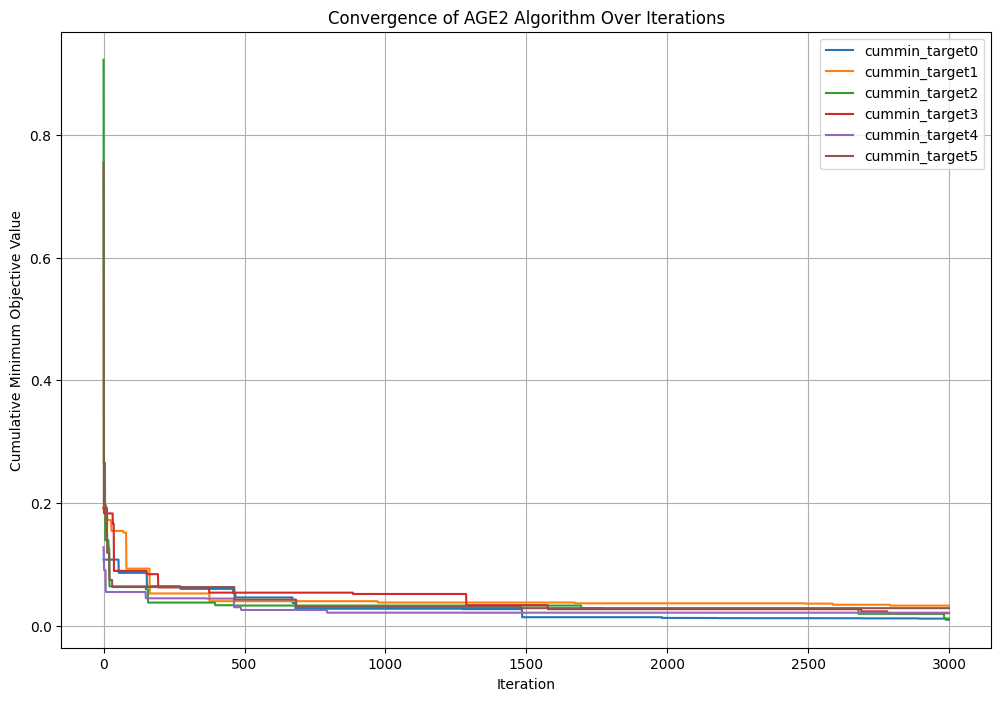

(3000, 6)


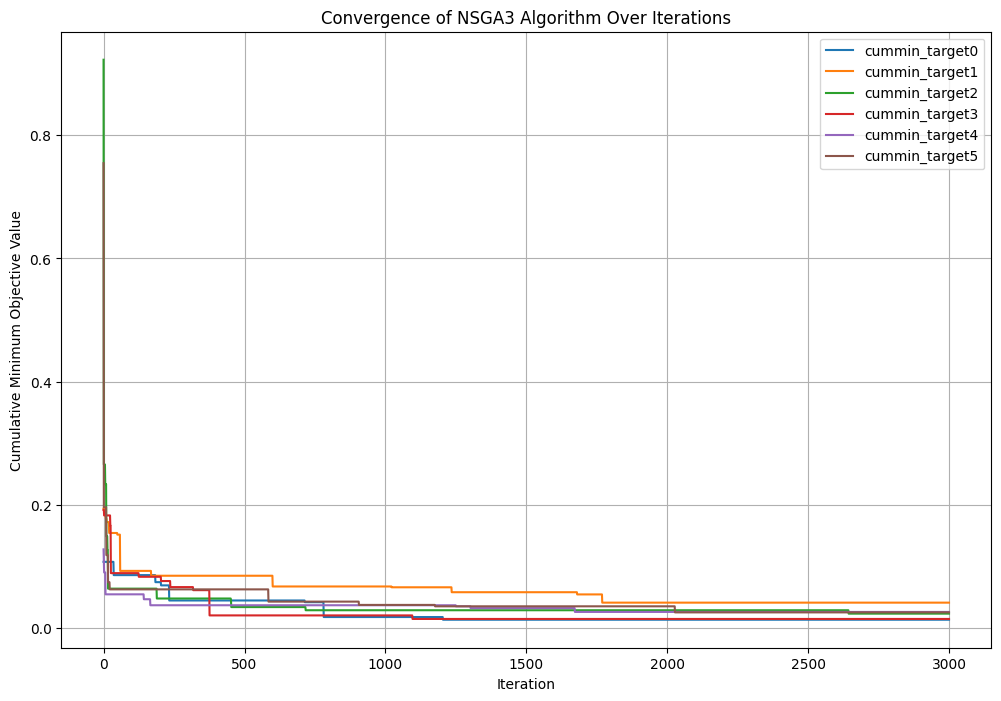

In [9]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# 文件列表
file_list = ['age2_result.pkl', 'nsga3_result.pkl']

# 处理每个文件
for file in file_list:
    # 从pickled文件中加载结果对象
    with open(f'../output/data_cache/{file}', 'rb') as f:
        res = pickle.load(f)
    
    # 获取历史对象
    history = res.history
    
    # 提取所有演算的目标值
    all_f = [entry.pop.get('F') for entry in history]
    
    # 将目标值展平
    flattened_f = np.vstack(all_f)
    print(flattened_f.shape) # (3000, 6)
    
    # 转换为DataFrame
    df = pd.DataFrame(flattened_f, columns=[f'target{i}' for i in range(flattened_f.shape[1])])
    for col in df.columns:
        df[f'cummin_{col}'] = df[col].cummin()

    # 绘图
    plt.figure(figsize=(12, 8))
    for col in df.columns:
        if col.startswith('cummin_'):
            plt.plot(df[col], label=f'{col}', linestyle='-')
    
    # 图示和标签
    plt.xlabel('Iteration')
    plt.ylabel('Cumulative Minimum Objective Value')
    plt.title(f'Convergence of {file.split("_")[0].upper()} Algorithm Over Iterations')
    plt.legend()
    plt.grid(True)
    plt.show()


0       2.298466
1       1.511744
2       3.211051
3       1.733716
4       1.932400
          ...   
2995    0.843485
2996    1.003731
2997    0.835092
2998    0.814195
2999    0.767234
Name: sum_targets, Length: 3000, dtype: float64


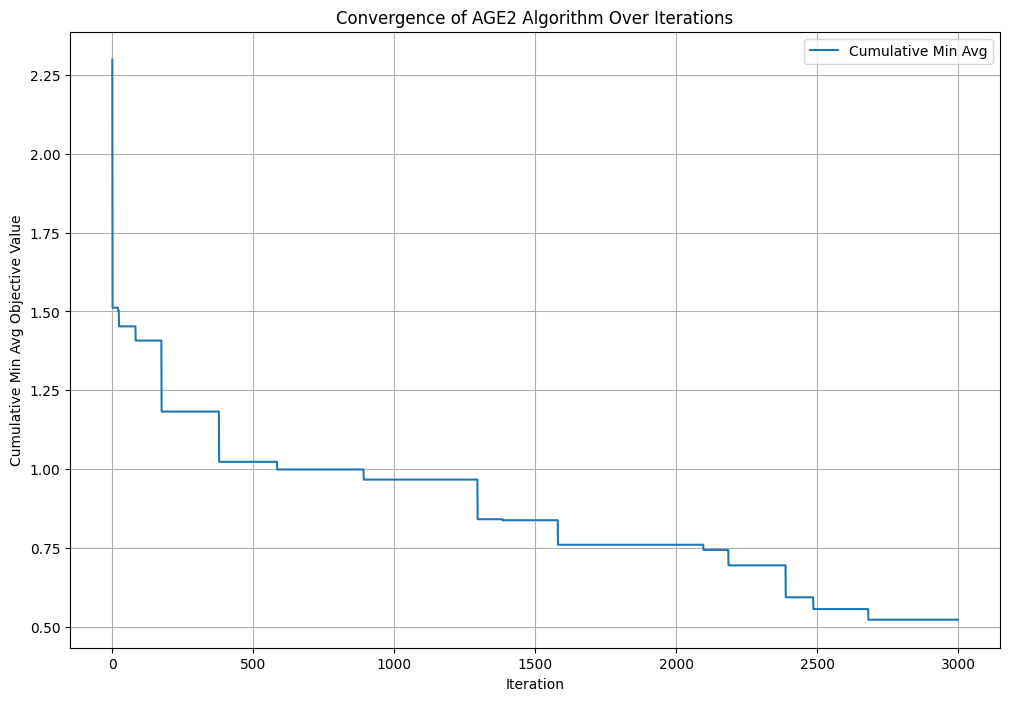

0       2.298466
1       1.511744
2       3.211051
3       1.733716
4       1.932400
          ...   
2995    1.068016
2996    1.192223
2997    1.697498
2998    1.382813
2999    1.351978
Name: sum_targets, Length: 3000, dtype: float64


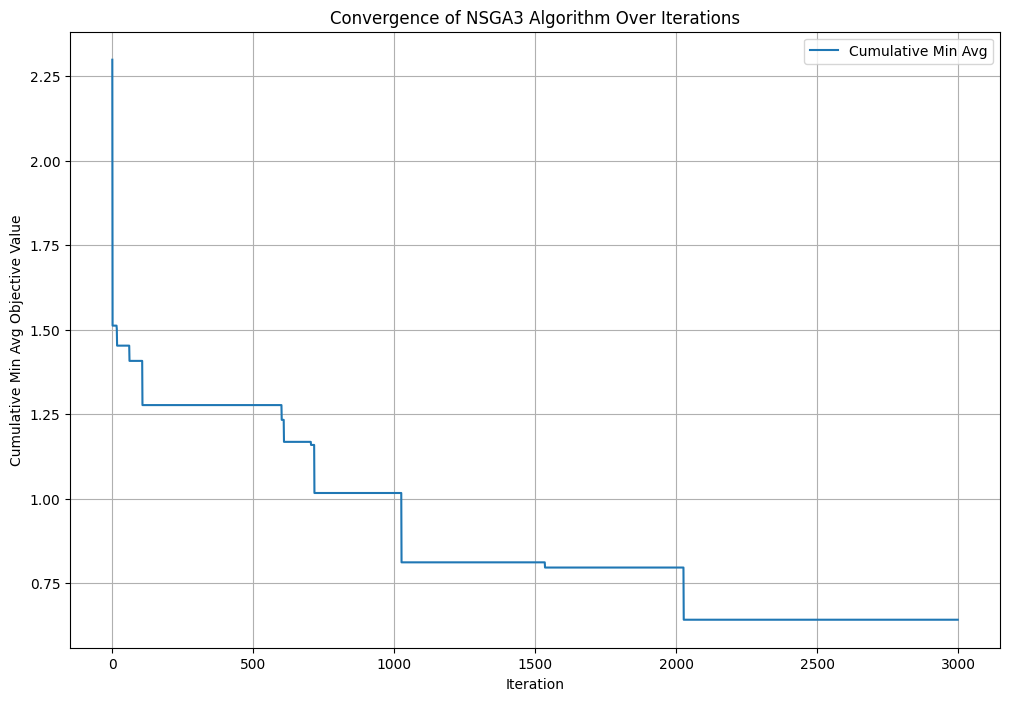

0      0.359116
1      0.416201
2      0.327593
3      0.386822
4      0.348668
         ...   
995    0.295268
996    0.294658
997    0.308638
998    0.298145
999    0.305837
Name: sum_targets, Length: 1000, dtype: float64


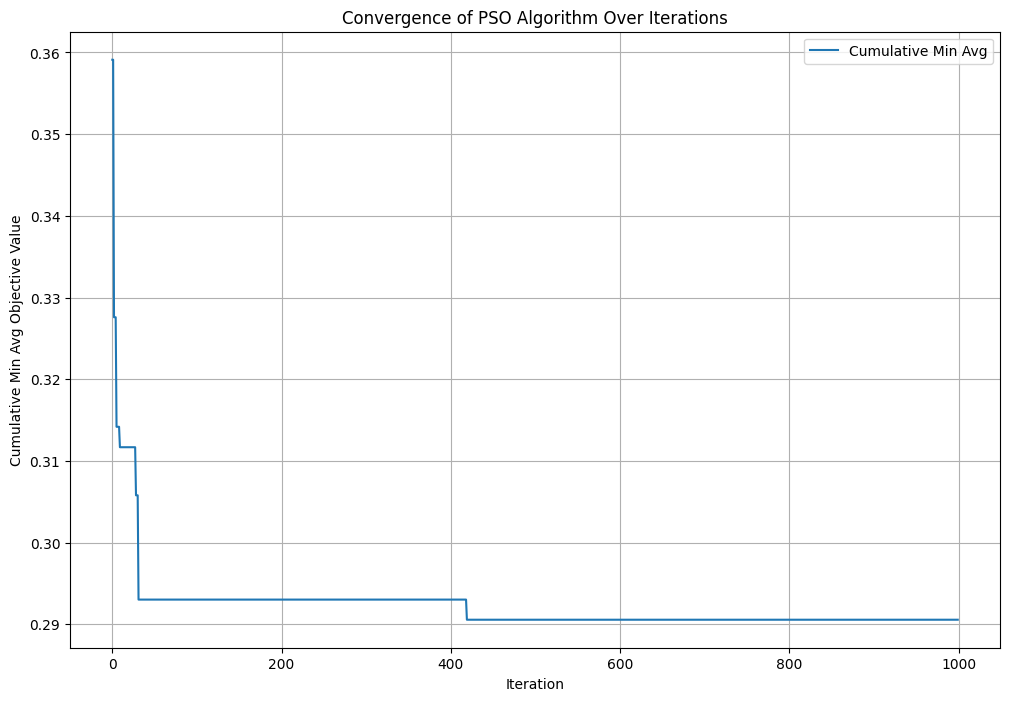

In [18]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 文件列表
file_list = ['age2_result.pkl', 'nsga3_result.pkl', "pso_result.pkl"]

# 处理每个文件
for file in file_list:
    # 从pickled文件中加载结果对象
    with open(f'../output/data_cache/{file}', 'rb') as f:
        res = pickle.load(f)
    
    # 获取历史对象
    history = res.history
    
    # 提取所有演算的目标值
    all_f = [entry.pop.get('F') for entry in history]
    
    # 将目标值展平
    flattened_f = np.vstack(all_f)
    
    # 转换为DataFrame
    df = pd.DataFrame(flattened_f, columns=[f'target{i}' for i in range(flattened_f.shape[1])])
    
    # 计算每行的目标值之和
    df['sum_targets'] = df.sum(axis=1)

    print(df['sum_targets']) # 打印形状，例如 (3000, 6)
    
    # 计算累计最小值
    df['cummin_sum_targets'] = df['sum_targets'].cummin()
    
    # 计算累计最小值的平均值
    df['cummin_avg'] = df['cummin_sum_targets']

    # 绘图
    plt.figure(figsize=(12, 8))
    plt.plot(df['cummin_avg'], label='Cumulative Min Avg', linestyle='-')
    
    # 图示和标签
    plt.xlabel('Iteration')
    plt.ylabel('Cumulative Min Avg Objective Value')
    plt.title(f'Convergence of {file.split("_")[0].upper()} Algorithm Over Iterations')
    plt.legend()
    plt.grid(True)
    plt.show()


X shape: (6000, 28)
Y shape: (6000, 6)

Sensitivity analysis results for age2_result.pkl:

Objective 1:
  car_tau_mean: -0.2335
  car_tau_std: 0.0242
  bus_tau_mean: -0.0604
  bus_tau_std: 0.0004
  car_acc: 0.6125
  car_dcc: 0.4571
  bus_acc: 0.0881
  bus_dcc: 0.1644
  car_sigma: -0.0593
  car_lcSigma: 0.1112
  bus_sigma: 0.1608
  bus_lcSigma: -0.1135
  car_v_mean: 0.3142
  car_v_std: -0.0381
  bus_v_mean: -0.0472
  bus_v_std: 0.0052
  car_lcSublane: 0.0560
  bus_lcSublane: 0.0118
  car_lcPushy: 0.0036
  bus_lcPushy: -0.0176
  car_lcSpeedGainRight: 0.1871
  bus_lcSpeedGainRight: 0.0918
  car_lcAssertive: 0.3430
  bus_lcAssertive: 0.1613
  car_lcCooperative: -0.0393
  bus_lcCooperative: -0.1390
  car_lcLookaheadLeft: 0.0451
  bus_lcLookaheadLeft: 0.0038

Objective 2:
  car_tau_mean: 0.0895
  car_tau_std: 0.3536
  bus_tau_mean: 0.0674
  bus_tau_std: -0.0068
  car_acc: -0.2834
  car_dcc: -0.1462
  bus_acc: -0.0469
  bus_dcc: 0.1053
  car_sigma: -0.1370
  car_lcSigma: -0.1782
  bus_sigma: 

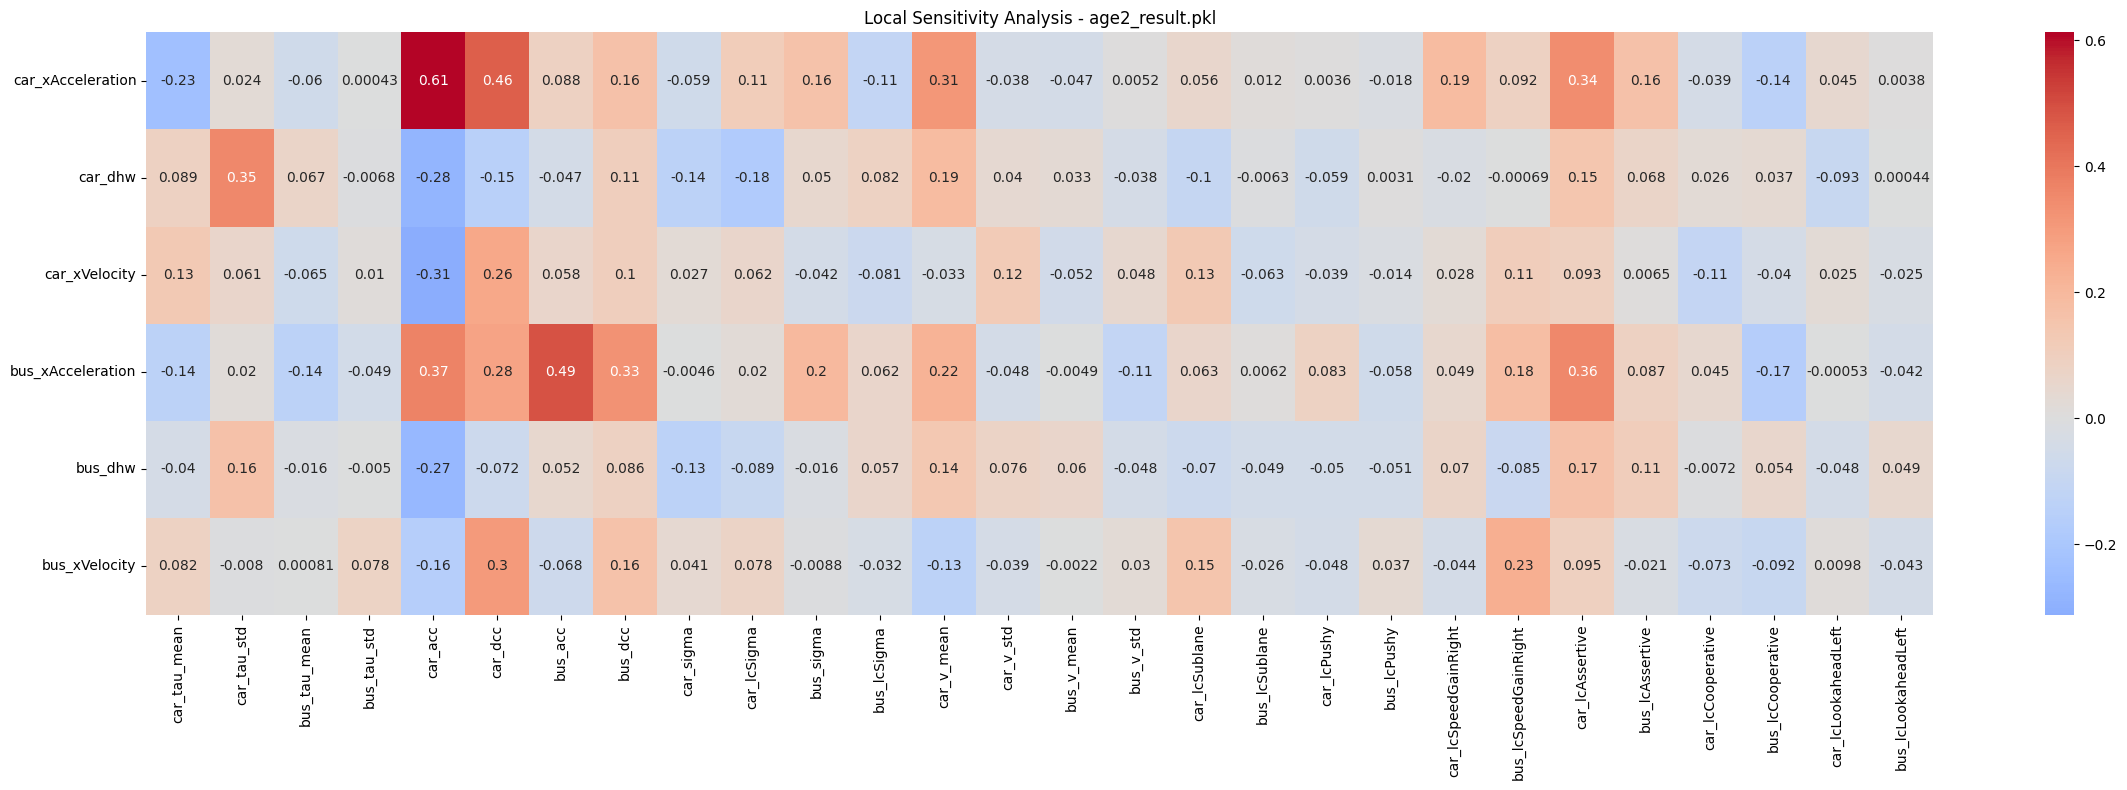

Combined X shape: (6000, 28)
Combined Y shape: (6000, 6)


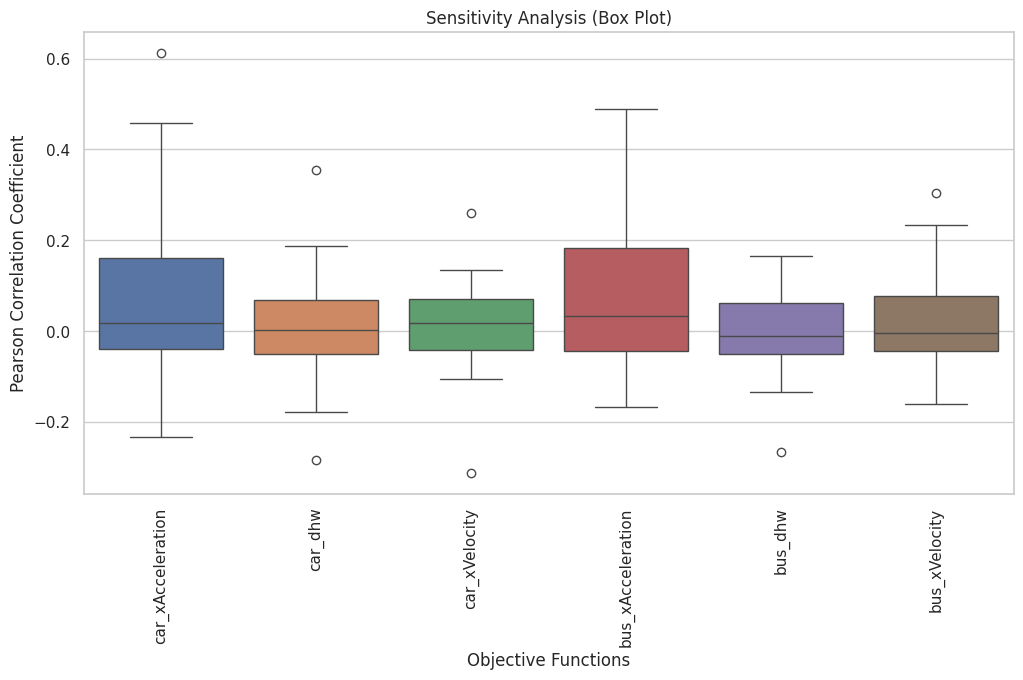

In [9]:
import numpy as np
import pickle
from scipy import stats
from task import pbounds

problem = {
    'num_vars': len(pbounds),
    'names': list(pbounds.keys()),
    'bounds': list(pbounds.values())
}
# objectis car_fi = ["xAcceleration", "dhw", "xVelocity"]
# bus_fi = ["xAcceleration", "dhw", "xVelocity"]
objectY = ["car_xAcceleration", "car_dhw", "car_xVelocity", "bus_xAcceleration", "bus_dhw", "bus_xVelocity"]

file_list = ['nsga3_result.pkl', 'age2_result.pkl']

combined_X = []
combined_Y = []

# Load and merge data from all files
for file in file_list:
    with open(f'../output/data_cache/{file}', 'rb') as f:
        res = pickle.load(f)
    
    # Get history object
    history = res.history

    # Aggregate X (parameters) and Y (objective values) from history
    X = np.array([s.pop.get("X") for s in history])
    Y = np.array([s.pop.get("F") for s in history])
    
    combined_X.append(X)
    combined_Y.append(Y)

# Combine all loaded arrays
X = np.vstack(combined_X)
Y = np.vstack(combined_Y)
Y = Y.reshape(-1, Y.shape[-1])
X = X.reshape(-1, X.shape[-1])
print(f"X shape: {X.shape}")  # (3000, 28)
print(f"Y shape: {Y.shape}")  # (3000, 6)

# Perform local sensitivity analysis using Pearson correlation coefficient
sensitivities = []
for i in range(Y.shape[1]):  # For each objective
    correlations = []
    for j in range(X.shape[1]):  # For each input parameter
        correlation, _ = stats.pearsonr(X[:, j], Y[:, i])
        correlations.append(correlation)
    sensitivities.append(correlations)

sensitivities = np.array(sensitivities)

# Print or visualise results
print(f"\nSensitivity analysis results for {file}:")
for i, obj_name in enumerate(["Objective " + str(i+1) for i in range(Y.shape[1])]):
    print(f"\n{obj_name}:")
    for j, param_name in enumerate(problem['names']):
        print(f"  {param_name}: {sensitivities[i, j]:.4f}")

# Optional: Visualise results using a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(24, 8))
sns.heatmap(sensitivities, annot=True, cmap='coolwarm', center=0,
            xticklabels=list(pbounds.keys()), yticklabels=objectY)
plt.title(f"Local Sensitivity Analysis - {file}")
plt.tight_layout()
plt.show()

objectY = ["car_xAcceleration", "car_dhw", "car_xVelocity", "bus_xAcceleration", "bus_dhw", "bus_xVelocity"]

file_list = ['nsga3_result.pkl', 'age2_result.pkl']

# Combined lists for X and Y
combined_X = []
combined_Y = []

# Load and merge data from all files
for file in file_list:
    with open(f'../output/data_cache/{file}', 'rb') as f:
        res = pickle.load(f)
    
    # Get history object
    history = res.history

    # Aggregate X (parameters) and Y (objective values) from history
    X = np.array([s.pop.get("X") for s in history])
    Y = np.array([s.pop.get("F") for s in history])
    
    combined_X.append(X)
    combined_Y.append(Y)

# Combine all loaded arrays
combined_X = np.vstack(combined_X)
combined_Y = np.vstack(combined_Y)

# Reshape combined_X and combined_Y
combined_X = combined_X.reshape(-1, combined_X.shape[-1])
combined_Y = combined_Y.reshape(-1, combined_Y.shape[-1])

print(f"Combined X shape: {combined_X.shape}")
print(f"Combined Y shape: {combined_Y.shape}")

# Perform local sensitivity analysis using Pearson correlation coefficient
sensitivities = []
for i in range(combined_Y.shape[1]):  # For each objective
    correlations = []
    for j in range(combined_X.shape[1]):  # For each input parameter
        correlation, _ = stats.pearsonr(combined_X[:, j], combined_Y[:, i])
        correlations.append(correlation)
    sensitivities.append(correlations)

sensitivities = np.array(sensitivities)
import pandas as pd
import seaborn as sns

# Convert sensitivities array to DataFrame for easy plotting
sensitivity_df = pd.DataFrame(sensitivities.T, index=problem['names'], columns=objectY)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(data=sensitivity_df)
plt.xlabel('Objective Functions')
plt.ylabel('Pearson Correlation Coefficient')
plt.title('Sensitivity Analysis (Box Plot)')
plt.xticks(rotation=90)
plt.show()
